# HPDM097 Assignment 2

## Iteration 11: Adding reciprocal of p(delay) to make it more interpretable (Gemini)

This is the 11th iteration to the code. Here we added the reciprocal of p(delay) to make the output of our model more easily interpretable for clinicians, ward managers and decision makers.

Prompt and response: https://gemini.google.com/share/3227ffa05b09

## Prompt:
I am happy with everything so far, for each table which display the results for the p(delay), can we also add the reciprocal (1/p(delay)) to make it more interpretable for clinicians? e.g. p(delay) = 0.02 means that 1 in every 50 patients will experience some delay in admission or transfer. Again use the iterative approach and add to previous code so we can compare all scenarios.

## Response
Translating abstract probabilities into "1 in X" clinical frequencies is a fantastic idea. It makes the data immediately relatable for ward managers and clinical leads who are thinking about individual patients on a shift, rather than systemic load percentages.

To do this, I have updated the print_table and print_partial_pooling_table functions. I added a mathematical safeguard to prevent a ZeroDivisionError when P(delay)=0 (which happens when you have an abundance of beds) by having it output "No delay" in those instances, and "Every patient" when P(delay)=1.0.

Here is the fully updated iterative code containing all 4 scenarios, the 6-pane plot, and the new clinical interpretation columns:

--- Running BASE Scenario Simulation ---

--- Running +5% ADMISSIONS Scenario Simulation ---

=== SCENARIO 1: BASE ACUTE BEDS ===
Mean Unconstrained Occupancy: 8.17 beds
Capacity | P(delay) | % Delayed | Clinical Frequency
------------------------------------------------------
      0  |  1.0000  |  100.00%  |     Every pt
      2  |  0.7568  |   75.68%  |       1 in 1
      4  |  0.6412  |   64.12%  |       1 in 2
      6  |  0.4233  |   42.33%  |       1 in 2
      8  |  0.2440  |   24.40%  |       1 in 4
     10  |  0.1371  |   13.71%  |       1 in 7
     12  |  0.0592  |    5.92%  |      1 in 17
     14  |  0.0206  |    2.06%  |      1 in 48
     16  |  0.0066  |    0.66%  |     1 in 152
     18  |  0.0003  |    0.03%  |    1 in 3647
     20  |  0.0003  |    0.03%  |    1 in 3650
     22  |  0.0000  |    0.00%  |     No delay
     24  |  0.0000  |    0.00%  |     No delay
     26  |  0.0000  |    0.00%  |     No delay

=== SCENARIO 1: BASE REHAB BEDS ===
Mean Unconstrained Occupanc

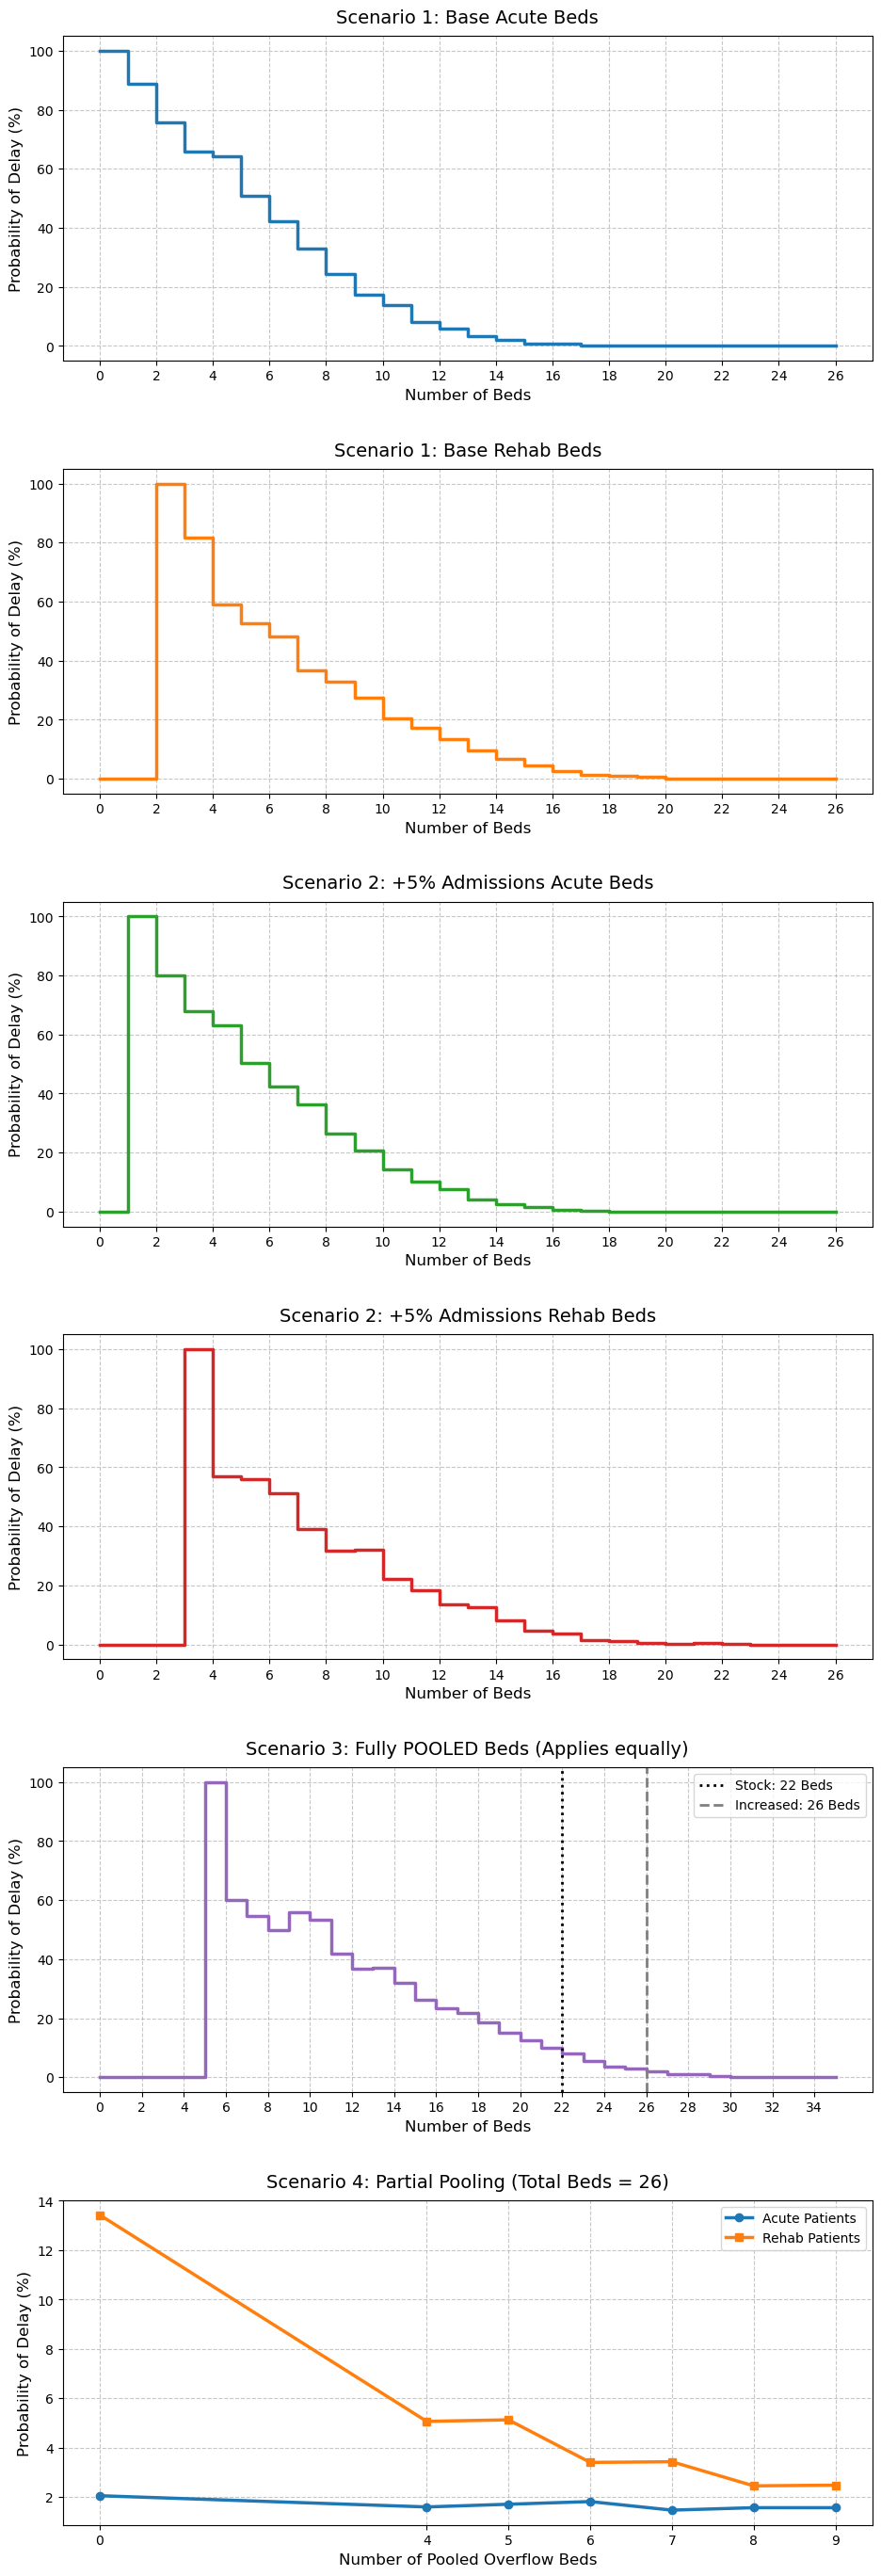

In [1]:
import simpy
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. Trace utility function as a debug print switch
# ---------------------------------------------------------
TRACE = False

def trace(msg):
    if TRACE:
        print(msg)

# ---------------------------------------------------------
# 1. Build and sample from distribution classes
# ---------------------------------------------------------
class ExponentialDistribution:
    def __init__(self, mean, random_seed=None):
        self.mean = mean
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.exponential(scale=self.mean)

class LognormalDistribution:
    def __init__(self, sample_mean, sample_stdev, random_seed=None):
        variance = sample_stdev ** 2
        self.mu = np.log((sample_mean ** 2) / np.sqrt(variance + sample_mean ** 2))
        self.sigma = np.sqrt(np.log(1 + (variance / sample_mean ** 2)))
        self.rng = np.random.default_rng(seed=random_seed)
        
    def sample(self):
        return self.rng.lognormal(mean=self.mu, sigma=self.sigma)

# ---------------------------------------------------------
# 3. Create a parameter container class called Scenario
# ---------------------------------------------------------
class Scenario:
    def __init__(self, admissions_multiplier=1.0):
        self.random_seed = 42
        
        self.warm_up_days = 3 * 365
        self.run_days = 10 * 365
        
        self.acute_beds_capacity = 9999 
        self.rehab_beds_capacity = 9999 
        
        self.separate_eval_range = range(0, 27) 
        self.pooled_eval_range = range(0, 36)   
        
        base_acute_iat = {
            'Acute stroke': 1.2, 'TIA': 9.3, 'Complex neurological': 3.6, 'Other': 3.2
        }
        self.acute_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_acute_iat.items()
        }
        
        base_rehab_iat = {
            'Acute stroke': 21.8, 'Complex neurological': 31.7, 'Other': 28.6
        }
        self.rehab_inter_arrival_means = {
            k: v / admissions_multiplier for k, v in base_rehab_iat.items()
        }
        
        self.acute_destinations = ['Rehab', 'ESD', 'Other']
        self.acute_transfer_matrix = {
            'Acute stroke': [0.24, 0.13, 0.63], 'TIA': [0.01, 0.01, 0.98],
            'Complex neurological': [0.11, 0.05, 0.84], 'Other': [0.05, 0.10, 0.85]
        }
        
        self.rehab_destinations = ['ESD', 'Other']
        self.rehab_transfer_matrix = {
            'Acute stroke': [0.40, 0.60], 'TIA': [0.00, 1.00],
            'Complex neurological': [0.09, 0.91], 'Other': [0.13, 0.87] 
        }
        
        self.acute_los_params = {
            'Acute stroke': {'Rehab': (7.4, 8.6), 'ESD': (4.6, 4.8), 'Other': (7.4, 8.6)},
            'TIA': {dest: (1.8, 2.3) for dest in self.acute_destinations},
            'Complex neurological': {dest: (4.0, 5.0) for dest in self.acute_destinations},
            'Other': {dest: (3.8, 5.2) for dest in self.acute_destinations}
        }
        
        self.rehab_los_params = {
            'Acute stroke': {'ESD': (30.3, 23.1), 'Other': (28.4, 27.2)},
            'TIA': {dest: (18.7, 23.5) for dest in self.rehab_destinations},
            'Complex neurological': {dest: (27.6, 28.4) for dest in self.rehab_destinations},
            'Other': {dest: (16.1, 14.1) for dest in self.rehab_destinations}
        }

# ---------------------------------------------------------
# 4. Create a patient class called AcutePatient
# ---------------------------------------------------------
class AcutePatient:
    def __init__(self, p_id, p_type, arrival_time, source="Acute"):
        self.id = p_id
        self.type = p_type
        self.arrival_time = arrival_time
        self.source = source
        self.acute_destination = None
        self.rehab_destination = None

# ---------------------------------------------------------
# 5. Create a model class called StrokeUnit
# ---------------------------------------------------------
class StrokeUnit:
    def __init__(self, env, scenario):
        self.env = env
        self.scenario = scenario
        self.patient_counter = 0
        
        self.daily_acute_occupancy = []
        self.daily_rehab_occupancy = []
        self.daily_total_occupancy = [] 
        
        self.acute_beds = simpy.Resource(env, capacity=self.scenario.acute_beds_capacity)
        self.rehab_beds = simpy.Resource(env, capacity=self.scenario.rehab_beds_capacity)
        
        self.acute_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 100)
        self.rehab_routing_rng = np.random.default_rng(seed=self.scenario.random_seed + 200)
        
        self.acute_arrival_dists = {}
        self.rehab_arrival_dists = {}
        self.acute_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        self.rehab_los_dists = {p_type: {} for p_type in self.scenario.acute_inter_arrival_means.keys()}
        
        dist_seed = self.scenario.random_seed + 1000
        
        for p_type, mean_iat in self.scenario.acute_inter_arrival_means.items():
            self.acute_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            for dest in self.scenario.acute_destinations:
                mean, stdev = self.scenario.acute_los_params[p_type][dest]
                self.acute_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1
                
        for p_type, mean_iat in self.scenario.rehab_inter_arrival_means.items():
            self.rehab_arrival_dists[p_type] = ExponentialDistribution(mean_iat, dist_seed)
            dist_seed += 1
            
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            for dest in self.scenario.rehab_destinations:
                mean, stdev = self.scenario.rehab_los_params[p_type][dest]
                self.rehab_los_dists[p_type][dest] = LognormalDistribution(mean, stdev, dist_seed)
                dist_seed += 1

    def daily_audit(self):
        yield self.env.timeout(self.scenario.warm_up_days)
        while True:
            acc = len(self.acute_beds.users)
            reh = len(self.rehab_beds.users)
            self.daily_acute_occupancy.append(acc)
            self.daily_rehab_occupancy.append(reh)
            self.daily_total_occupancy.append(acc + reh)
            yield self.env.timeout(1.0)

    def acute_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.acute_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Acute")
            self.env.process(self.acute_process(patient))

    def rehab_direct_arrivals_generator(self, patient_type):
        while True:
            yield self.env.timeout(self.rehab_arrival_dists[patient_type].sample())
            self.patient_counter += 1
            patient = AcutePatient(self.patient_counter, patient_type, self.env.now, "Direct Rehab")
            self.env.process(self.rehab_process(patient))

    def acute_process(self, patient):
        probs = self.scenario.acute_transfer_matrix[patient.type]
        patient.acute_destination = self.acute_routing_rng.choice(self.scenario.acute_destinations, p=probs)
        with self.acute_beds.request() as req:
            yield req
            los = self.acute_los_dists[patient.type][patient.acute_destination].sample()
            yield self.env.timeout(los)
            if patient.acute_destination == 'Rehab':
                self.env.process(self.rehab_process(patient))

    def rehab_process(self, patient):
        probs = self.scenario.rehab_transfer_matrix[patient.type]
        patient.rehab_destination = self.rehab_routing_rng.choice(self.scenario.rehab_destinations, p=probs)
        with self.rehab_beds.request() as req:
            yield req
            los = self.rehab_los_dists[patient.type][patient.rehab_destination].sample()
            yield self.env.timeout(los)

    def run_simulation(self):
        self.env.process(self.daily_audit())
        for p_type in self.scenario.acute_inter_arrival_means.keys():
            self.env.process(self.acute_arrivals_generator(p_type))
        for p_type in self.scenario.rehab_inter_arrival_means.keys():
            self.env.process(self.rehab_direct_arrivals_generator(p_type))

# =========================================================
# Analysis & Plotting Functions
# =========================================================
def calculate_p_delay_curve(occupancy_data, capacity_range):
    if not occupancy_data: return {}
    counts = np.zeros(max(max(capacity_range), max(occupancy_data)) + 1)
    for occ in occupancy_data: counts[occ] += 1
    pdf = counts / len(occupancy_data)
    cdf = np.cumsum(pdf)
    return {n: (pdf[n] / cdf[n] if cdf[n] > 0 else 0.0) for n in capacity_range}

def calculate_partial_pooling_delay(acute_occ, rehab_occ, c_a, c_r, c_p):
    """Calculates multidimensional Erlang blocking for an overflow model."""
    joint_counts = {}
    for a, r in zip(acute_occ, rehab_occ):
        joint_counts[(a, r)] = joint_counts.get((a, r), 0) + 1
        
    p_valid, p_block_a, p_block_r = 0.0, 0.0, 0.0
    total_samples = len(acute_occ)
    
    for (a, r), count in joint_counts.items():
        prob = count / total_samples
        overflow_a = max(0, a - c_a)
        overflow_r = max(0, r - c_r)
        total_overflow = overflow_a + overflow_r
        
        if total_overflow <= c_p:
            p_valid += prob
            if a >= c_a and total_overflow == c_p: p_block_a += prob
            if r >= c_r and total_overflow == c_p: p_block_r += prob
                
    if p_valid > 0:
        return p_block_a / p_valid, p_block_r / p_valid
    return 0.0, 0.0

def print_table(title, occupancy_data, results, highlight_beds=None):
    print(f"\n{title}")
    if occupancy_data: print(f"Mean Unconstrained Occupancy: {np.mean(occupancy_data):.2f} beds")
    print("Capacity | P(delay) | % Delayed | Clinical Frequency")
    print("------------------------------------------------------")
    for beds, p_delay in results.items():
        marker = " <---" if highlight_beds and beds in highlight_beds else ""
        
        # Calculate clinical frequency logic (1 in X)
        if p_delay == 0.0:
            clin_freq = "No delay"
        elif p_delay == 1.0:
            clin_freq = "Every pt"
        else:
            clin_freq = f"1 in {round(1/p_delay)}"
            
        if beds % 2 == 0 or marker: 
            print(f" {beds:6d}  |  {p_delay:.4f}  | {p_delay*100:7.2f}%  | {clin_freq:>12}{marker}")

def print_partial_pooling_table(title, results):
    print(f"\n{title}")
    print("Total Fixed Beds = 26")
    print(" Acute | Rehab | Pooled || Acute P(delay) | Acute Freq   || Rehab P(delay) | Rehab Freq")
    print("-----------------------------------------------------------------------------------------")
    for (ca, cr, cp), (p_a, p_r) in results.items():
        # Acute clinical frequency
        a_freq = "No delay" if p_a == 0.0 else ("Every pt" if p_a == 1.0 else f"1 in {round(1/p_a)}")
        # Rehab clinical frequency
        r_freq = "No delay" if p_r == 0.0 else ("Every pt" if p_r == 1.0 else f"1 in {round(1/p_r)}")
        
        print(f"   {ca:2d}  |   {cr:2d}  |   {cp:2d}   ||    {p_a*100:6.2f}%     | {a_freq:>10} ||    {p_r*100:6.2f}%     | {r_freq:>10}")

def plot_all_tradeoff_curves(base_a, base_r, inc_a, inc_r, pooled, partial_results):
    fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(10, 28))
    
    datasets = [
        (base_a, 'Scenario 1: Base Acute Beds', '#1f77b4'),
        (base_r, 'Scenario 1: Base Rehab Beds', '#ff7f0e'),
        (inc_a, 'Scenario 2: +5% Admissions Acute Beds', '#2ca02c'),
        (inc_r, 'Scenario 2: +5% Admissions Rehab Beds', '#d62728'),
        (pooled, 'Scenario 3: Fully POOLED Beds (Applies equally)', '#9467bd')
    ]
    
    # Plot Scenarios 1 to 3
    for ax, (data_dict, title, color) in zip(axes[:5], datasets):
        beds = list(data_dict.keys())
        p_delay_pct = [val * 100 for val in data_dict.values()]
        ax.step(beds, p_delay_pct, where='post', color=color, linewidth=2.5)
        ax.set_title(title, fontsize=14, pad=10)
        ax.set_xlabel('Number of Beds', fontsize=12)
        ax.set_ylabel('Probability of Delay (%)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_xticks(beds[::2])
        ax.set_ylim(-5, 105)
        if 'POOLED' in title:
            ax.axvline(x=22, color='black', linestyle=':', linewidth=2, label='Stock: 22 Beds')
            ax.axvline(x=26, color='gray', linestyle='--', linewidth=2, label='Increased: 26 Beds')
            ax.legend()
            
    # Plot Scenario 4 (Partial Pooling)
    ax6 = axes[5]
    pooled_counts = [cfg[2] for cfg in partial_results.keys()]
    acute_delays = [res[0] * 100 for res in partial_results.values()]
    rehab_delays = [res[1] * 100 for res in partial_results.values()]
    
    ax6.plot(pooled_counts, acute_delays, marker='o', color='#1f77b4', linewidth=2.5, label='Acute Patients')
    ax6.plot(pooled_counts, rehab_delays, marker='s', color='#ff7f0e', linewidth=2.5, label='Rehab Patients')
    ax6.set_title('Scenario 4: Partial Pooling (Total Beds = 26)', fontsize=14, pad=10)
    ax6.set_xlabel('Number of Pooled Overflow Beds', fontsize=12)
    ax6.set_ylabel('Probability of Delay (%)', fontsize=12)
    ax6.grid(True, linestyle='--', alpha=0.7)
    ax6.set_xticks(pooled_counts)
    ax6.legend()

    plt.tight_layout(pad=3.0)
    plt.show()

# =========================================================
# Execution
# =========================================================
if __name__ == "__main__":
    # --- 1. Run Base Scenario ---
    print("--- Running BASE Scenario Simulation ---")
    base_scenario = Scenario(admissions_multiplier=1.0)
    env_base = simpy.Environment()
    model_base = StrokeUnit(env_base, base_scenario)
    model_base.run_simulation()
    env_base.run(until=base_scenario.warm_up_days + base_scenario.run_days)
    
    base_acute_res = calculate_p_delay_curve(model_base.daily_acute_occupancy, base_scenario.separate_eval_range)
    base_rehab_res = calculate_p_delay_curve(model_base.daily_rehab_occupancy, base_scenario.separate_eval_range)
    pooled_res = calculate_p_delay_curve(model_base.daily_total_occupancy, base_scenario.pooled_eval_range)

    # Calculate Scenario 4 (Partial Pooling) configs
    partial_configs = [
        (14, 12, 0), # Baseline 26 total
        (11, 11, 4), 
        (11, 10, 5), 
        (10, 10, 6), 
        (10, 9, 7),  
        (9,  9,  8),  
        (9,  8,  9)   
    ]
    partial_results = {}
    for c_a, c_r, c_p in partial_configs:
        p_a, p_r = calculate_partial_pooling_delay(
            model_base.daily_acute_occupancy, model_base.daily_rehab_occupancy, c_a, c_r, c_p
        )
        partial_results[(c_a, c_r, c_p)] = (p_a, p_r)

    # --- 2. Run +5% Scenario ---
    print("\n--- Running +5% ADMISSIONS Scenario Simulation ---")
    inc_scenario = Scenario(admissions_multiplier=1.05)
    env_inc = simpy.Environment()
    model_inc = StrokeUnit(env_inc, inc_scenario)
    model_inc.run_simulation()
    env_inc.run(until=inc_scenario.warm_up_days + inc_scenario.run_days)
    
    inc_acute_res = calculate_p_delay_curve(model_inc.daily_acute_occupancy, inc_scenario.separate_eval_range)
    inc_rehab_res = calculate_p_delay_curve(model_inc.daily_rehab_occupancy, inc_scenario.separate_eval_range)

    # --- 3. Output Tables ---
    print_table("=== SCENARIO 1: BASE ACUTE BEDS ===", model_base.daily_acute_occupancy, base_acute_res)
    print_table("=== SCENARIO 1: BASE REHAB BEDS ===", model_base.daily_rehab_occupancy, base_rehab_res)
    print_table("=== SCENARIO 2: +5% ADMISSIONS ACUTE ===", model_inc.daily_acute_occupancy, inc_acute_res)
    print_table("=== SCENARIO 2: +5% ADMISSIONS REHAB ===", model_inc.daily_rehab_occupancy, inc_rehab_res)
    print_table("=== SCENARIO 3: FULLY POOLED BEDS ===", model_base.daily_total_occupancy, pooled_res, highlight_beds=[22, 26])
    print_partial_pooling_table("=== SCENARIO 4: PARTIAL POOLING ===", partial_results)

    # --- 4. Plotting ---
    print("\nGenerating Matplotlib visualization...")
    plot_all_tradeoff_curves(base_acute_res, base_rehab_res, inc_acute_res, inc_rehab_res, pooled_res, partial_results)